In [56]:
#Importando bibliotecas nescessarias
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

In [57]:
#Carregando os dados
casas = fetch_california_housing(as_frame = True)
df = casas.frame
print("Primeiras 5 linhas do dataset")
print(df.head())

#Separando x(dados) y(alvo)
X = casas.data
y = casas.target
print(X.shape, y.shape)
print("20,640 amostras com 8 características + o valor medio")

print(casas.feature_names)


Primeiras 5 linhas do dataset
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
(20640, 8) (20640,)
20,640 amostras com 8 características + o valor medio
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [58]:
#Separando o dataset para treino e para teste
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=13)
print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


Nota: A Análise Exploratória de Dados (EDA) e as visualizações estatísticas abaixo foram realizadas exclusivamente sobre o conjunto de treino para evitar vazamento de informação analítica (Data Leakage) e preservar a integridade do conjunto de teste como avaliação cega.

Valor maximo de uma casa em centenas de dolares: 5.00001


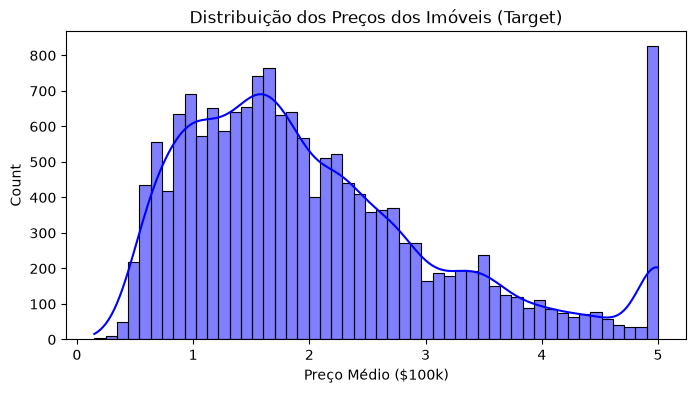

In [59]:
#Comportamento da variavel alvo
print(f"Valor maximo de uma casa em centenas de dolares: {y_train.max()}")
plt.figure(figsize=(8,4))
sns.histplot(y_train, kde=True, bins=50, color="blue")
plt.title('Distribuição dos Preços dos Imóveis (Target)')
plt.xlabel('Preço Médio ($100k)')
plt.show()

A analise do comportamento do vetor de alvo indica duas coisas pricipais: 1- Entre 300k e 500k existe uma queda na quantidade de casas com esse valor, fator normal no mundo imobiliario onde existem  muitas casas baratas e conforme o preco sobe a quantidade de casas diminui drasticamente; 2- Em relacao ao grande pico em 500k estudando a origem do dataset descobre-se que no senso americano de 1990 (data e origem desses dados) havia um teto programado onde qualquer imovel com preco maior que $500.001 era registrado como 5.00001, esse pico artificial é um problema para o algoritimo pois ao tentar prever uma mansao de 1 milhao de dolares, por exemplo, o modelo resultaria em um preco proximo a 500k pois e assim que imoveis semelhantes foram tratados nesse dataset.  

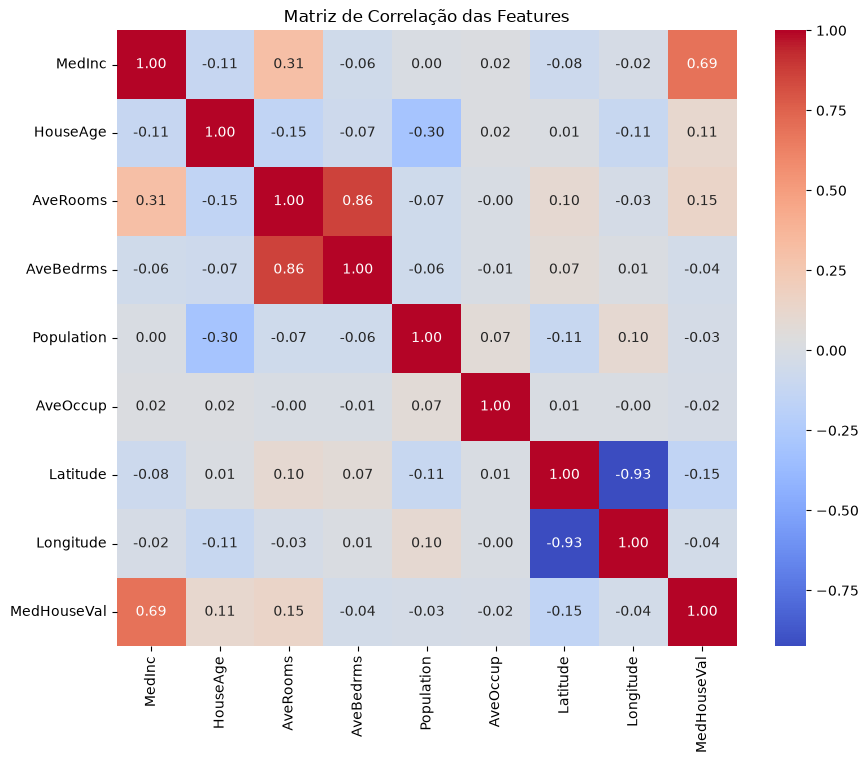

In [60]:
#Analisando quais features tem mais impacto no preco
df_train = pd.DataFrame(X_train, columns=casas.feature_names)
df_train['MedHouseVal'] = y_train

plt.figure(figsize=(10,8))
sns.heatmap(df_train.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação das Features")
plt.show()

Através da análise da Matriz de Correlação no conjunto de treino, percebe-se uma forte correlação linear positiva de 0.69 entre Renda Média (MedInc) e Valor do Imóvel (MedHouseVal), justificando a adequação do uso de modelos de Regressão Linear para este problema. Além disso, foi observada forte colinearidade entre o número de cômodos e o número de quartos (0.86).


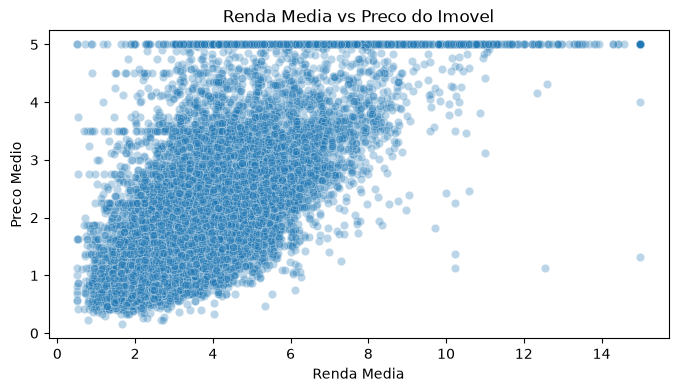

In [61]:
#Analizando linearidade em relacao a feature mais significativa

plt.figure(figsize=(8,4))
sns.scatterplot(x=df_train['MedInc'], y=df_train['MedHouseVal'], alpha = 0.3)
plt.title("Renda Media vs Preco do Imovel")
plt.xlabel("Renda Media")
plt.ylabel("Preco Medio")
plt.show()

Como o gráfico apresenta uma dispersão em formato de nuvem com inclinação diagonal ascendente, valida-se a relação linear positiva entre as variáveis, justificando o uso da Regressão Linear. Além disso, é possível notar a presença de alguns outliers, confirmar visualmente o problema do teto artificial de preço fixado em $500k (linha horizontal no topo do gráfico) e perceber especies de "linhas de corte", após pesquisa sobre o dataset é  possivel concluir que essas linhas ocorrem pois muitos analistas simplesmente arredondaram os preços das casas para valores fechados como 250k e 350k.

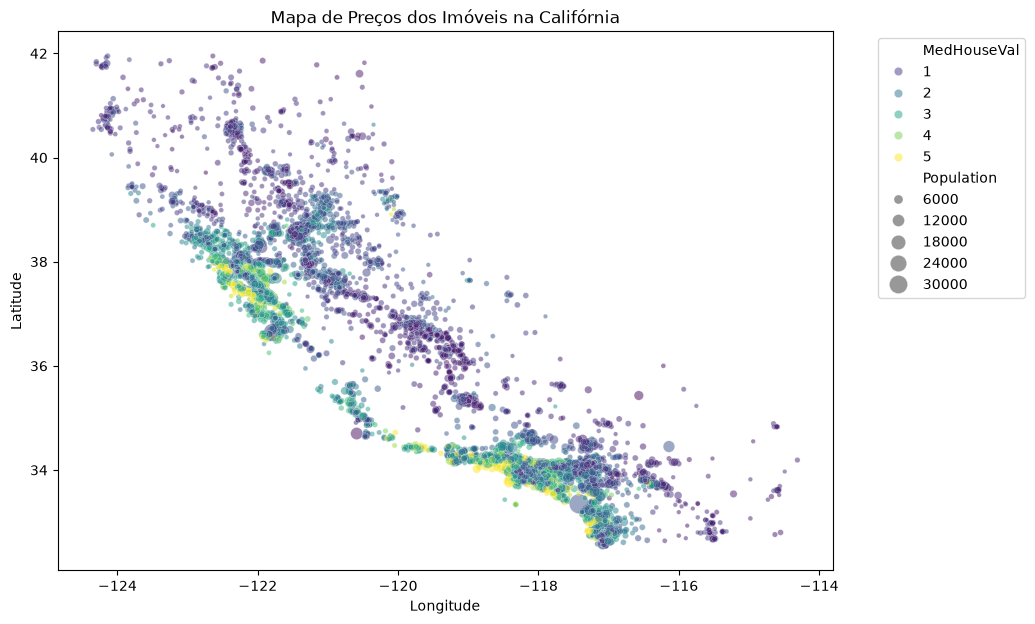

In [62]:
#Gráfico Geográfico
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_train['Longitude'], 
    y=df_train['Latitude'], 
    size=df_train['Population'], 
    hue=df_train['MedHouseVal'], 
    palette='viridis', 
    alpha=0.5,
    sizes=(10, 200)
)
plt.title('Mapa de Preços dos Imóveis na Califórnia')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

Esse gráfico geográfico mostra o mapa da Califórnia e, com base nisso, percebe-se que os imóveis mais caros ficam concentrados no litoral, em cidades como São Francisco e Los Angeles, enquanto no interior os imóveis são bem mais baratos.

In [ ]:
# Seleção de Atributos: Removendo variável redundante por alta multicolinearidade
colunas_para_remover = ['AveBedrms']

X_train = X_train.drop(columns=colunas_para_remover)
X_test = X_test.drop(columns=colunas_para_remover)

print("Shape do Treino após remoção:", X_train.shape)
print("Shape do Teste após remoção:", X_test.shape)

Shape do Treino após remoção: (16512, 7)
Shape do Teste após remoção: (4128, 7)


Seleção de Atributos - Tratamento de Multicolinearidade:Durante a Análise Exploratória, identifiquei uma forte colinearidade (r = 0.86) entre as variáveis AveRooms (Média total de cômodos) e AveBedrms (Média de dormitórios). A presença de atributos altamente correlacionados em modelos de Regressão Linear distorce a estimação dos coeficientes (beta) e inflaciona a variância do modelo (Multicolinearidade). Analisando a correlação com a variável alvo (MedHouseVal), constatou-se que AveRooms possui maior poder explicativo (r = 0.15) em comparação com AveBedrms (r = -0.04). Portanto, a variável AveBedrms foi removida dos conjuntos de treino e teste para simplificar a arquitetura do modelo e garantir a estabilidade matemática da regressão.

In [64]:
#Padronizando as escalas dos dados
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)